---
title: "Lab 3: Federalist Papers"
author: "Shiqi Wu"
format:
  html:
    embed-resources: true
    code-overflow: wrap
    include-in-header:
      text: |
        <style>
        .cell-output-display figure {
          width: 100%;
          max-width: 100%;
        }
        .cell-output-display img {
          max-width: 100% !important;
          height: auto !important;
        }
        </style>
---

## Question 0

Answer: I would start by looking at the average word-use pattern of each author. I would use word proportions instead of raw counts because the papers have different lengths. Then I would average these proportions for Hamilton, Jay, and Madison separately. For each disputed paper, I would use cosine distance to find the closest author average and predict that author. I would also test this method on papers with known authorship. When testing a paper, I would leave it out of the averages so it does not influence its own prediction.

## Question 1

In [1]:
import pandas as pd

In [2]:
authorship = pd.read_csv("https://dlsun.github.io/pods/data/federalist/authorship.csv")

authorship.head()

,Paper,Author
0,1,Hamilton
1,2,Jay
2,3,Jay
3,4,Jay
4,5,Jay


In [3]:
print("Total papers:", len(authorship))

authorship["Author"].value_counts(dropna=False)

Total papers: 85


Author
Hamilton    51
NaN         15
Madison     14
Jay          5
Name: count, dtype: int64

In [4]:
from urllib.request import urlopen

base_url = "https://dlsun.github.io/pods/data/federalist/"

with urlopen(base_url + "1.txt") as response: paper_1 = response.read().decode("utf-8")

print(paper_1[:1000])

To the People of the State of New York:

AFTER an unequivocal experience of the inefficacy of the subsisting
federal government, you are called upon to deliberate on a new
Constitution for the United States of America. The subject speaks its
own importance; comprehending in its consequences nothing less than the
existence of the UNION, the safety and welfare of the parts of which it
is composed, the fate of an empire in many respects the most interesting
in the world. It has been frequently remarked that it seems to have been
reserved to the people of this country, by their conduct and example,
to decide the important question, whether societies of men are really
capable or not of establishing good government from reflection and
choice, or whether they are forever destined to depend for their
political constitutions on accident and force. If there be any truth
in the remark, the crisis at which we are arrived may with propriety be
regarded as the era in which that decision is to be mad

In [5]:
texts = []

for paper_number in authorship["Paper"]:
    with urlopen(base_url + f"{paper_number}.txt") as response:
        text = response.read().decode("utf-8")
        texts.append(text)

authorship["Text"] = texts

print("Papers loaded:", len(texts))
authorship[["Paper", "Author", "Text"]].head()

Papers loaded: 85


,Paper,Author,Text
0,1,Hamilton,To the People of the State of New York:\n\nAFT...
1,2,Jay,To the People of the State of New York:\n\nWHE...
2,3,Jay,To the People of the State of New York:\n\nIT ...
3,4,Jay,To the People of the State of New York:\n\nMY ...
4,5,Jay,To the People of the State of New York:\n\nQUE...


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=50,
    lowercase=True,
    token_pattern=r"(?u)\b[a-zA-Z]+\b"
)

word_counts = vectorizer.fit_transform(authorship["Text"])

tf = pd.DataFrame(
    word_counts.toarray(),
    index=authorship["Paper"],
    columns=vectorizer.get_feature_names_out()
)

print("Matrix shape:", tf.shape)
tf.head()

Matrix shape: (85, 50)


,a,all,an,and,any,are,as,at,be,been,...,their,them,they,this,those,to,which,will,with,would
Paper,,,,,,,,,,,,,,,,,,,,,
1,25,9,11,40,6,12,10,8,34,3,...,14,2,6,14,9,72,18,25,6,2
2,30,4,1,83,1,6,16,10,15,8,...,21,4,22,14,2,53,11,2,13,5
3,13,4,3,60,5,8,24,1,31,2,...,11,8,5,6,6,56,11,24,10,2
4,16,4,3,90,5,11,20,2,26,2,...,19,12,17,1,4,51,10,15,12,17
5,9,4,4,72,3,3,3,4,31,0,...,11,11,11,6,9,45,10,7,11,37


In [7]:
top_word_counts = tf.sum(axis=0).sort_values(ascending=False)

print(top_word_counts.to_string())

the             17767
of              11824
to               7074
and              5099
in               4456
a                3991
be               3825
that             2792
it               2550
is               2194
which            2068
by               1741
as               1721
this             1410
would            1273
have             1262
will             1255
for              1237
or               1233
not              1215
their            1098
with             1053
from             1043
are              1032
on                952
they              928
an                927
states            851
government        829
may               816
been              798
state             787
all               731
but               697
its               651
other             646
people            612
power             603
has               603
more              579
at                568
if                563
than              550
them              548
one               547
any       

## Question 2

In [8]:
analyzer = vectorizer.build_analyzer()

total_words = pd.Series(
    [len(analyzer(text)) for text in authorship["Text"]],
    index=authorship["Paper"]
)

word_proportions = tf.div(total_words, axis=0)

word_proportions.head()

,a,all,an,and,any,are,as,at,be,been,...,their,them,they,this,those,to,which,will,with,would
Paper,,,,,,,,,,,,,,,,,,,,,
1,0.015432,0.005556,0.006790,0.024691,0.003704,0.007407,0.006173,0.004938,0.020988,0.001852,...,0.008642,0.001235,0.003704,0.008642,0.005556,0.044444,0.011111,0.015432,0.003704,0.001235
2,0.017910,0.002388,0.000597,0.049552,0.000597,0.003582,0.009552,0.005970,0.008955,0.004776,...,0.012537,0.002388,0.013134,0.008358,0.001194,0.031642,0.006567,0.001194,0.007761,0.002985
3,0.008972,0.002761,0.002070,0.041408,0.003451,0.005521,0.016563,0.000690,0.021394,0.001380,...,0.007591,0.005521,0.003451,0.004141,0.004141,0.038647,0.007591,0.016563,0.006901,0.001380
4,0.009721,0.002430,0.001823,0.054678,0.003038,0.006683,0.012151,0.001215,0.015796,0.001215,...,0.011543,0.007290,0.010328,0.000608,0.002430,0.030984,0.006075,0.009113,0.007290,0.010328
5,0.006686,0.002972,0.002972,0.053492,0.002229,0.002229,0.002229,0.002972,0.023031,0.000000,...,0.008172,0.008172,0.008172,0.004458,0.006686,0.033432,0.007429,0.005201,0.008172,0.027489


In [9]:
author_labels = authorship.set_index("Paper")["Author"]

known_word_proportions = word_proportions.join(author_labels).dropna(
    subset=["Author"]
)

author_means = known_word_proportions.groupby("Author").mean()

author_means

,a,all,an,and,any,are,as,at,be,been,...,their,them,they,this,those,to,which,will,with,would
Author,,,,,,,,,,,,,,,,,,,,,
Hamilton,0.022082,0.003800,0.005711,0.023993,0.003224,0.004990,0.008492,0.003366,0.020796,0.004179,...,0.005160,0.002575,0.004613,0.007983,0.002821,0.041034,0.010934,0.006364,0.005476,0.008429
Jay,0.011421,0.002801,0.002010,0.048721,0.002554,0.005762,0.011467,0.002601,0.018758,0.001820,...,0.009782,0.005711,0.009780,0.004463,0.004186,0.034540,0.006742,0.008573,0.007234,0.009041
Madison,0.019182,0.003890,0.004232,0.029959,0.002026,0.005264,0.009611,0.002013,0.019428,0.004962,...,0.006114,0.002978,0.004713,0.006319,0.001975,0.032223,0.011131,0.006652,0.005440,0.004079


In [10]:
top_10_words = top_word_counts.head(10).index.tolist()

plot_data = (
    author_means[top_10_words]
    .reset_index()
    .melt(
        id_vars="Author",
        var_name="Word",
        value_name="Mean proportion"
    )
)

plot_data["Mean percentage"] = plot_data["Mean proportion"] * 100

plot_data.head(9)

,Author,Word,Mean proportion,Mean percentage
0,Hamilton,the,0.092752,9.275181
1,Jay,the,0.060895,6.089487
2,Madison,the,0.101024,10.102358
3,Hamilton,of,0.064618,6.461770
4,Jay,of,0.043641,4.364096
5,Madison,of,0.060029,6.002904
6,Hamilton,to,0.041034,4.103447
7,Jay,to,0.034540,3.454046
8,Madison,to,0.032223,3.222305


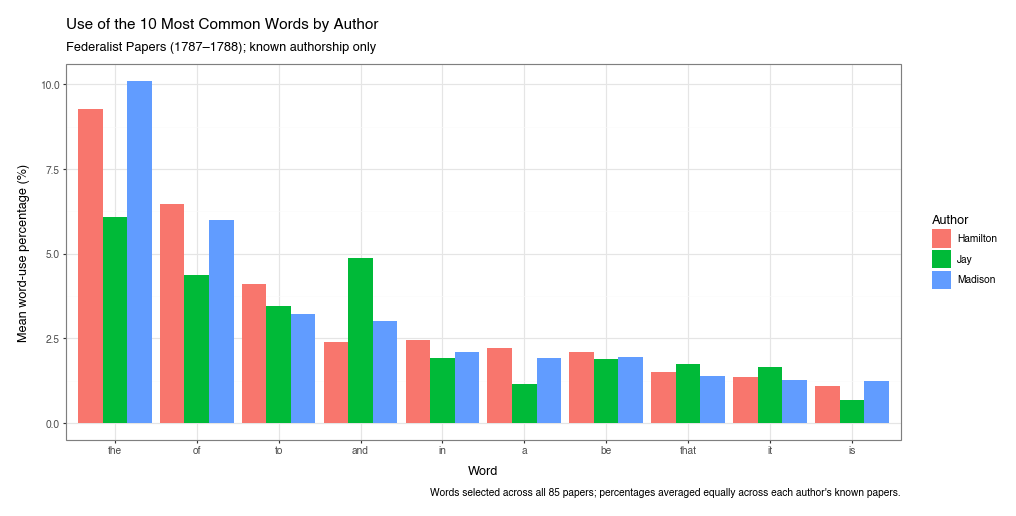

In [11]:
from plotnine import (ggplot, aes, geom_col, scale_x_discrete,labs, theme_bw, theme)

common_words_plot = (
    ggplot(plot_data, aes(x="Word", y="Mean percentage", fill="Author"))
    + geom_col(position="dodge")
    + scale_x_discrete(limits=top_10_words)
    + labs(
        title="Use of the 10 Most Common Words by Author",
        subtitle="Federalist Papers (1787–1788); known authorship only",
        x="Word",
        y="Mean word-use percentage (%)",
        fill="Author",
        caption="Words selected across all 85 papers; percentages averaged equally across each author's known papers."
    )
    + theme_bw()
    + theme(figure_size=(12, 6))
)

common_words_plot

In [12]:
selected_words = ["the", "and", "of", "to"]

distribution_data = (
    known_word_proportions[["Author"] + selected_words]
    .reset_index()
    .melt(
        id_vars=["Paper", "Author"],
        var_name="Word",
        value_name="Proportion"
    )
)

distribution_data["Percentage"] = distribution_data["Proportion"] * 100

distribution_data.head()

,Paper,Author,Word,Proportion,Percentage
0,1,Hamilton,the,0.082099,8.209877
1,2,Jay,the,0.063881,6.388060
2,3,Jay,the,0.064182,6.418219
3,4,Jay,the,0.052248,5.224787
4,5,Jay,the,0.049034,4.903418


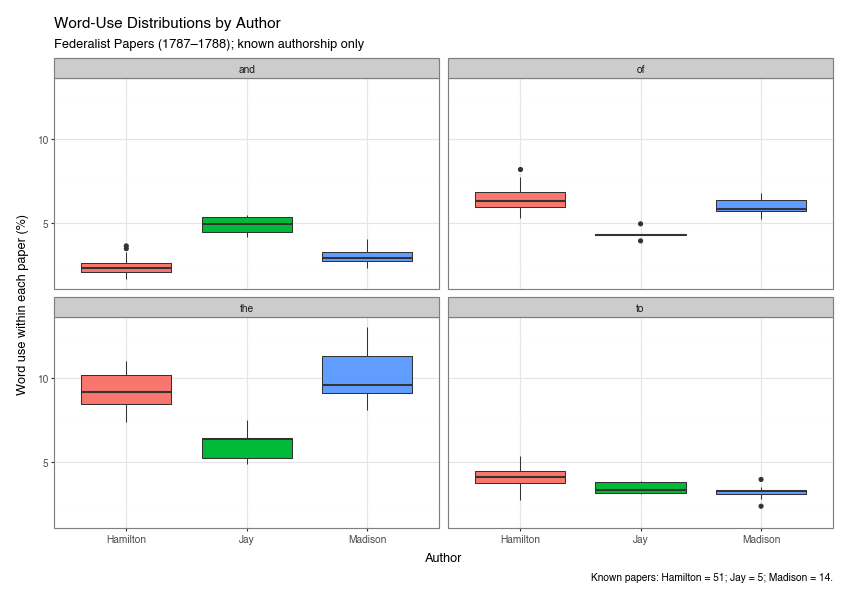

In [13]:
from plotnine import geom_boxplot, facet_wrap

word_distribution_plot = (
    ggplot(distribution_data, aes(x="Author", y="Percentage", fill="Author"))
    + geom_boxplot()
    + facet_wrap("~Word", ncol=2)
    + labs(
        title="Word-Use Distributions by Author",
        subtitle="Federalist Papers (1787–1788); known authorship only",
        x="Author",
        y="Word use within each paper (%)",
        caption="Known papers: Hamilton = 51; Jay = 5; Madison = 14."
    )
    + theme_bw()
    + theme(figure_size=(10, 7), legend_position="none")
)

word_distribution_plot

Answer: The authors share many common words, but they use them in different proportions. Jay uses “and” more often on average than Hamilton and Madison, while using “the” and “of” less often. Hamilton has the highest average proportions of “of” and “to,” while Madison has the highest average proportion of “the.” The boxplots also show variation between papers by the same author and some overlap between authors, especially Hamilton and Madison for “the.” These patterns may help identify authors, but they do not show that authorship can be predicted perfectly. Jay’s results should also be interpreted carefully because only five of his papers have known authorship.

## Question 3

Answer: I would use the 50 common words to compare each disputed paper with the average word-use pattern of each known author. I would first convert the counts into proportions of each paper’s total word count, then calculate the average proportions for Hamilton, Jay, and Madison. For each disputed paper, I would calculate its cosine distance from these three averages and predict the author with the smallest distance. This would compare overall word-use patterns rather than relying on just one word.

## Question 4

In [14]:
known_authors = author_labels.dropna()
unknown_papers = author_labels[author_labels.isna()].index

known_tf = tf.loc[known_authors.index]
unknown_tf = tf.loc[unknown_papers]

print("Known-author matrix:", known_tf.shape)
print("Unknown-author matrix:", unknown_tf.shape)

Known-author matrix: (70, 50)
Unknown-author matrix: (15, 50)


In [15]:
from sklearn.metrics.pairwise import cosine_distances

unknown_distances = pd.DataFrame(
    cosine_distances(unknown_tf, known_tf),
    index=unknown_tf.index,
    columns=known_tf.index
)

print("Distance matrix shape:", unknown_distances.shape)
unknown_distances.iloc[:5, :5]

Distance matrix shape: (15, 70)


Paper,1,2,3,4,5
Paper,,,,,
18,0.061632,0.090580,0.115726,0.137888,0.169384
19,0.049542,0.080077,0.093595,0.111900,0.143169
20,0.050083,0.072254,0.083555,0.108667,0.145524
49,0.035983,0.091068,0.088727,0.122651,0.140053
50,0.042740,0.080244,0.075090,0.102152,0.120383


In [16]:
paper_number = unknown_tf.index[0]

nearest_5 = unknown_distances.loc[paper_number].nsmallest(5)

neighbor_details = pd.DataFrame({
    "Cosine distance": nearest_5,
    "Author": known_authors.loc[nearest_5.index]
})

print("Disputed paper:", paper_number)
neighbor_details

Disputed paper: 18


,Cosine distance,Author
Paper,,
47,0.017801,Madison
17,0.026036,Hamilton
69,0.028209,Hamilton
44,0.028862,Madison
40,0.031263,Madison


In [17]:
votes = neighbor_details["Author"].value_counts()

predicted_author = votes.index[0]

print(votes)
print("Predicted author:", predicted_author)

Author
Madison     3
Hamilton    2
Name: count, dtype: int64
Predicted author: Madison


In [18]:
def predict_author(distances):
    nearest = distances.nsmallest(5)
    neighbor_authors = known_authors.loc[nearest.index]
    votes = neighbor_authors.value_counts()

    tied_authors = votes[votes == votes.max()].index

    return sorted(tied_authors)[0]

predict_author(unknown_distances.loc[18])

'Madison'

In [19]:
unknown_predictions = unknown_distances.apply(predict_author, axis=1)

disputed_results = unknown_predictions.to_frame(name="Predicted author")

disputed_results

,Predicted author
Paper,
18,Madison
19,Madison
20,Madison
49,Hamilton
50,Madison
51,Madison
52,Hamilton
53,Madison
54,Madison


Answer: Using the five closest known papers based on cosine distance, I would attribute papers 49, 52, 55, and 56 to Hamilton. I would attribute papers 18, 19, 20, 50, 51, 53, 54, 57, 58, 62, and 63 to Madison. None of the disputed papers were predicted to be by Jay. Each prediction uses the author with the most votes among the five nearest papers. My code breaks ties by choosing the author whose name comes first alphabetically. These are predictions from this method, not confirmed authorships.

## Question 5

In [20]:
known_distances = pd.DataFrame(
    cosine_distances(known_tf, known_tf),
    index=known_tf.index,
    columns=known_tf.index
)

print("Distance matrix shape:", known_distances.shape)
known_distances.iloc[:5, :5]

Distance matrix shape: (70, 70)


Paper,1,2,3,4,5
Paper,,,,,
1,0.000000,0.077098,0.061007,0.103700,0.129889
2,0.077098,0.000000,0.068120,0.048805,0.077460
3,0.061007,0.068120,0.000000,0.036448,0.082395
4,0.103700,0.048805,0.036448,0.000000,0.042767
5,0.129889,0.077460,0.082395,0.042767,0.000000


In [21]:
known_predictions = known_distances.apply(
    lambda distances: predict_author(
        distances.drop(index=distances.name)
    ),
    axis=1
)

known_results = pd.DataFrame({
    "Actual author": known_authors,
    "Predicted author": known_predictions
})

print("Number of papers:", len(known_results))
known_results

Number of papers: 70


,Actual author,Predicted author
Paper,,
1,Hamilton,Hamilton
2,Jay,Madison
3,Jay,Hamilton
4,Jay,Jay
5,Jay,Jay
...,...,...
81,Hamilton,Hamilton
82,Hamilton,Hamilton
83,Hamilton,Hamilton


## Question 6

In [22]:
evaluation_results = known_results.copy()

evaluation_results["Correct"] = (
    evaluation_results["Actual author"]
    == evaluation_results["Predicted author"]
)

accuracy_by_actual = (
    evaluation_results.groupby("Actual author")["Correct"]
    .agg(["sum", "count", "mean"])
    .rename(columns={
        "sum": "Correct predictions",
        "count": "Actual papers",
        "mean": "Proportion correct"
    })
)

accuracy_by_actual

,Correct predictions,Actual papers,Proportion correct
Actual author,,,
Hamilton,51,51,1.000000
Jay,2,5,0.400000
Madison,13,14,0.928571


Answer: The method correctly predicted all 51 Hamilton papers, 2 of the 5 Jay papers, and 13 of the 14 Madison papers. It worked well for identifying the known Hamilton and Madison papers, but it missed most of Jay’s papers. This shows that the method does not work equally well for all three authors. Jay also has only five known papers, so each incorrect prediction has a large effect on his proportion.

## Question 7

In [23]:
accuracy_by_predicted = (
    evaluation_results.groupby("Predicted author")["Correct"]
    .agg(["sum", "count", "mean"])
    .rename(columns={
        "sum": "Correct predictions",
        "count": "Predicted papers",
        "mean": "Proportion correct"
    })
)

accuracy_by_predicted

,Correct predictions,Predicted papers,Proportion correct
Predicted author,,,
Hamilton,51,53,0.962264
Jay,2,2,1.000000
Madison,13,15,0.866667


Answer: Of the 53 papers predicted to be by Hamilton, 51 were actually his. Both papers predicted to be by Jay were his, and 13 of the 15 papers predicted to be by Madison were his. These proportions were about 96.23%, 100%, and 86.67%, respectively. From this perspective, most predictions were correct for each author. However, Jay’s 100% is based on only two predictions. It does not mean the method identified all of his papers, since Question 6 showed that it correctly identified only two of his five known papers.